<a href="https://colab.research.google.com/github/aanyagautam1923/student-performance-data-handling/blob/main/student_performance_data_handling_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving student_dataset_v2 (1).csv to student_dataset_v2 (1) (1).csv


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("student_dataset_v2 (1).csv")

# Display first and last records
print("First 5 records:\n", df.head())
print("\nLast 5 records:\n", df.tail())

# Shape, columns, datatypes
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)


First 5 records:
    ID       Name  StudyHours  Attendance  Marks
0   1  Student_1         4.4          96   59.5
1   2  Student_2         9.6          61   60.0
2   3  Student_3         7.6          65   80.2
3   4  Student_4         6.4          73   99.6
4   5  Student_5         2.4          68   79.7

Last 5 records:
        ID          Name  StudyHours  Attendance  Marks
995   996   Student_996         1.8          87   82.4
996   997   Student_997         9.3          57   43.8
997   998   Student_998         2.2          99   90.4
998   999   Student_999         9.6          52   40.2
999  1000  Student_1000         5.0          93   54.8

Shape: (1000, 5)

Columns: ['ID', 'Name', 'StudyHours', 'Attendance', 'Marks']

Data Types:
 ID              int64
Name           object
StudyHours    float64
Attendance      int64
Marks         float64
dtype: object


In [ ]:
# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Duplicates
print("\nDuplicate Records:", df.duplicated().sum())

# Descriptive statistics
print("\nDescriptive Statistics:\n", df.describe())

# Memory usage
df.info()



Missing Values:
 ID             0
Name           0
StudyHours     0
Attendance     0
Marks         49
dtype: int64

Duplicate Records: 0

Descriptive Statistics:
                 ID   StudyHours   Attendance       Marks
count  1000.000000  1000.000000  1000.000000  951.000000
mean    500.500000     5.413500    75.122000   69.991377
std     288.819436     2.630701    14.692208   17.287756
min       1.000000     1.000000    50.000000   40.000000
25%     250.750000     3.100000    62.000000   55.600000
50%     500.500000     5.500000    75.000000   70.300000
75%     750.250000     7.700000    88.000000   85.100000
max    1000.000000    10.000000   100.000000   99.900000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          1000 non-null   int64  
 1   Name        1000 non-null   object 
 2   StudyHours  1000 non-null   float64
 3   Attendan

In [ ]:
def clean_data(df):
    df = df.drop_duplicates()
    df['Marks'] = df['Marks'].fillna(df['Marks'].mean())
    df = df[(df['Attendance'] >= 0) & (df['Attendance'] <= 100)]
    df = df[(df['StudyHours'] >= 0) & (df['StudyHours'] <= 24)]
    df = df[(df['Marks'] >= 0) & (df['Marks'] <= 100)]
    df.to_csv("output/cleaned_data.csv", index=False)
    return df


In [ ]:
def assign_grade(marks):
    if marks >= 90: return 'A'
    elif marks >= 75: return 'B'
    elif marks >= 60: return 'C'
    elif marks >= 40: return 'D'
    else: return 'F'

df['Grade'] = df['Marks'].apply(assign_grade)
df['Result'] = df['Marks'].apply(lambda x: 'Pass' if x >= 40 else 'Fail')
df['PerformanceScore'] = (0.5*df['Marks'] + 0.3*df['Attendance'] + 0.2*df['StudyHours'])

In [ ]:
toppers = df[df['Grade'] == 'A']
failed_students = df[df['Result'] == 'Fail']
low_attendance = df[df['Attendance'] < 75]
hardworking = df[df['StudyHours'] > 8]

toppers.to_csv("toppers.csv", index=False)
failed_students.to_csv("failed_students.csv", index=False)
low_attendance.to_csv("low_attendance.csv", index=False)
hardworking.to_csv("hardworking.csv", index=False)


In [ ]:
print("Average Marks:", df['Marks'].mean())
print("Highest Marks:", df['Marks'].max())
print("Lowest Marks:", df['Marks'].min())
print("Average Attendance:", df['Attendance'].mean())
print("Average Study Hours:", df['StudyHours'].mean())

pass_count = df['Result'].value_counts().get('Pass', 0)
fail_count = df['Result'].value_counts().get('Fail', 0)
total_students = len(df)

print("Pass %:", (pass_count / total_students) * 100)
print("Fail %:", (fail_count / total_students) * 100)
print("Grade Distribution:\n", df['Grade'].value_counts())

Average Marks: 69.9913774973712
Highest Marks: 99.9
Lowest Marks: 40.0
Average Attendance: 75.122
Average Study Hours: 5.4135
Pass %: 100.0
Fail %: 0.0
Grade Distribution:
 Grade
D    310
C    290
B    251
A    149
Name: count, dtype: int64


In [ ]:
print("\nSorted by Marks:\n", df.sort_values(by='Marks', ascending=False).head())
print("\nSorted by Attendance:\n", df.sort_values(by='Attendance', ascending=False).head())
print("\nSorted by Study Hours:\n", df.sort_values(by='StudyHours', ascending=False).head())


Sorted by Marks:
       ID         Name  StudyHours  Attendance  Marks Grade Result  \
341  342  Student_342         5.3          84   99.9     A   Pass   
299  300  Student_300         1.8          53   99.8     A   Pass   
114  115  Student_115         6.7          99   99.8     A   Pass   
630  631  Student_631         7.4          59   99.7     A   Pass   
102  103  Student_103         3.8          79   99.7     A   Pass   

     PerformanceScore  
341             76.21  
299             66.16  
114             80.94  
630             69.03  
102             74.31  

Sorted by Attendance:
       ID         Name  StudyHours  Attendance  Marks Grade Result  \
38    39   Student_39         7.2         100   58.2     D   Pass   
331  332  Student_332         7.8         100   87.3     B   Pass   
252  253  Student_253         8.7         100   96.2     A   Pass   
222  223  Student_223         1.8         100   79.4     B   Pass   
575  576  Student_576         9.5         100   87.3 

In [ ]:
print("\nAverage Marks by Grade:\n", df.groupby('Grade')['Marks'].mean())
print("\nNumber of Students in each Grade:\n", df['Grade'].value_counts())
print("\nAverage Attendance by Grade:\n", df.groupby('Grade')['Attendance'].mean())


Average Marks by Grade:
 Grade
A    95.003356
B    82.627888
C    67.930267
D    49.666129
Name: Marks, dtype: float64

Number of Students in each Grade:
 Grade
D    310
C    290
B    251
A    149
Name: count, dtype: int64

Average Attendance by Grade:
 Grade
A    76.073826
B    74.577689
C    75.434483
D    74.812903
Name: Attendance, dtype: float64


In [ ]:
print("Mean:", df['Marks'].mean())
print("Median:", df['Marks'].median())
print("Mode:", df['Marks'].mode()[0])
print("Std Dev:", df['Marks'].std())
print("Variance:", df['Marks'].var())
print("\nCorrelation Matrix:\n", df[['StudyHours', 'Attendance', 'Marks', 'PerformanceScore']].corr())

Mean: 69.9913774973712
Median: 69.99137749737118
Mode: 69.99137749737118
Std Dev: 16.858451194346134
Variance: 284.2073766721506

Correlation Matrix:
                   StudyHours  Attendance     Marks  PerformanceScore
StudyHours          1.000000    0.033247  0.021274          0.088214
Attendance          0.033247    1.000000  0.029419          0.483840
Marks               0.021274    0.029419  1.000000          0.887318
PerformanceScore    0.088214    0.483840  0.887318          1.000000


In [ ]:
report = {
    "Total Students": len(df),
    "Passed Students": (df['Result'] == 'Pass').sum(),
    "Failed Students": (df['Result'] == 'Fail').sum(),
    "Highest Marks": df['Marks'].max(),
    "Lowest Marks": df['Marks'].min(),
    "Average Marks": df['Marks'].mean(),
    "Average Attendance": df['Attendance'].mean(),
    "Grade Distribution": df['Grade'].value_counts().to_dict()
}

report_df = pd.DataFrame(list(report.items()), columns=['Metric','Value'])
report_df.to_csv("report.csv", index=False)
print(report_df)

               Metric                                     Value
0      Total Students                                      1000
1     Passed Students                                      1000
2     Failed Students                                         0
3       Highest Marks                                      99.9
4        Lowest Marks                                      40.0
5       Average Marks                                 69.991377
6  Average Attendance                                    75.122
7  Grade Distribution  {'D': 310, 'C': 290, 'B': 251, 'A': 149}


In [ ]:
# Already exported cleaned_data.csv, toppers.csv, failed_students.csv, report.csv
print("Data exported successfully!")


Data exported successfully!


/tmp/ipykernel_9952/497043148.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Grade', order=['A', 'B', 'C', 'D', 'F'], palette='magma')


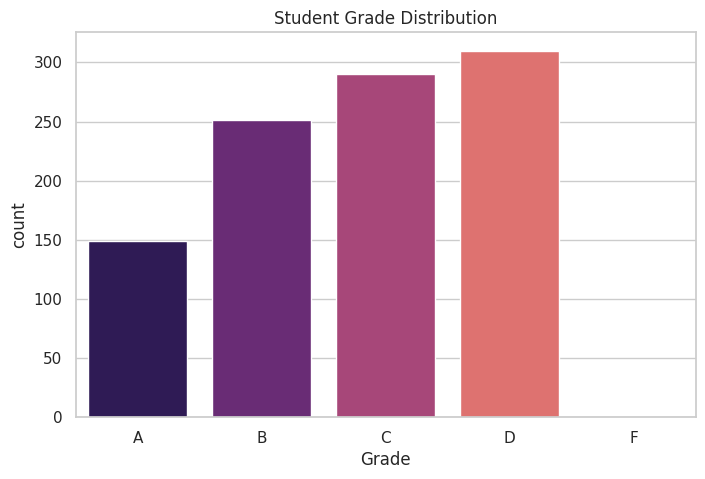

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style='whitegrid')

# 1. Distribution of Grades
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Grade', order=['A', 'B', 'C', 'D', 'F'], palette='magma')
plt.title('Student Grade Distribution')
plt.show()

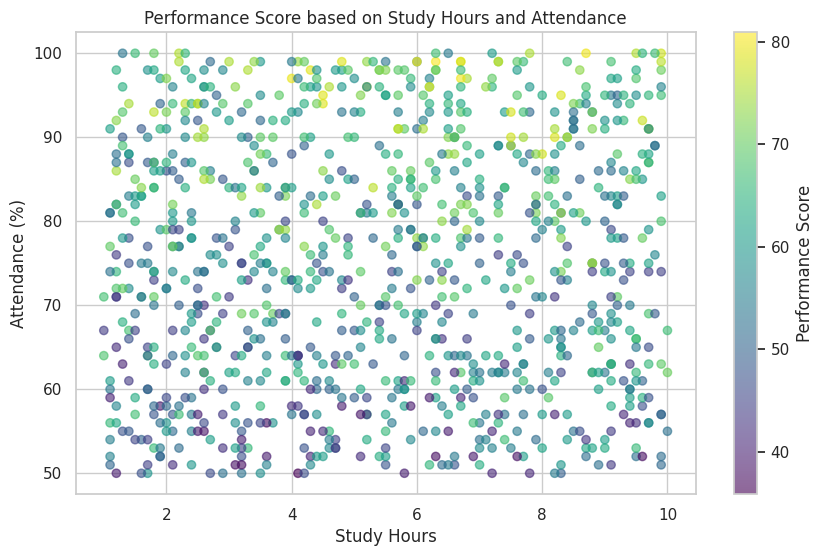

In [ ]:
# 2. Relationship between Study Hours, Attendance, and Performance Score
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['StudyHours'], df['Attendance'], c=df['PerformanceScore'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Performance Score')
plt.xlabel('Study Hours')
plt.ylabel('Attendance (%)')
plt.title('Performance Score based on Study Hours and Attendance')
plt.show()

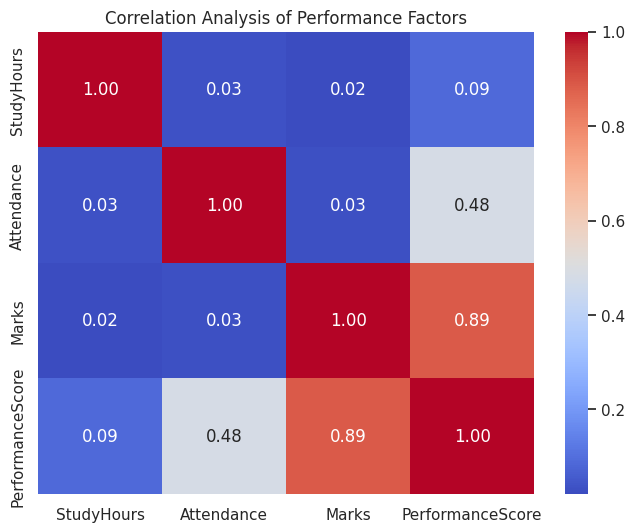

In [ ]:
# 3. Bonus Question Analysis: Correlation Matrix
plt.figure(figsize=(8, 6))
corr = df[['StudyHours', 'Attendance', 'Marks', 'PerformanceScore']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Analysis of Performance Factors')
plt.show()